# 第4章 CliffWalking：崖のそばを歩く（SARSA と Q学習）

4 × 12 のマス目の左下にスタートが、右下にゴールがあります。その間の下の段は、ずっと崖です。1歩進むごとに報酬が -1 され、崖に落ちると -100 されてスタートへ戻されます。いちばん早くゴールに着く道は、崖のふちを右へまっすぐ進む 13 歩の道です。ただし、試行錯誤の途中で、ときどきわざとでたらめな向きを試すとしたらどうでしょう。崖のふちでそれをすると、崖に落ちてしまうかもしれません。

この章では、この **CliffWalking** を、第3章の Q学習と、新しく紹介する **SARSA** の2つの手法で解きます。2つの手法は、どちらも同じように試行錯誤し、同じ ε-greedy で行動を選びます。違うのは、表を書き換える1行だけです。ところが、学んだあとに選ぶ道は、はっきり分かれます。まず、用意したサンプルを動かして、2つの手法が選ぶ道と、学習中の成績を見比べます。次に、サンプルを読んで、その1行の違いが、なぜ違う道につながるのかを確かめます。最後に、でたらめな行動を混ぜる割合を変えて遊びます。

- **前提**: [第3章 FrozenLake](../ch03_frozenlake/ch03_frozenlake.ipynb)を終えていること
- **所要の目安**: 実行は CPU で 1 分ほど
- **使う装置**: CPU だけで動きます（計算は NumPy だけです）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、NumPy 2.5.3）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. CliffWalking の状態・行動・報酬と、崖に落ちたときの扱いを説明できる
2. 用意した SARSA と Q学習のサンプルを動かし、学んだ道と、学習中の報酬を比べられる
3. SARSA と Q学習の違いが、サンプルのどの1行に当たるかを説明できる
4. 方策オンと方策オフの違いを、2つの手法が選ぶ道の違いと結びつけて説明できる

完了条件は、この Notebook を上から最後まで実行して、4節で、Q学習の学んだ道が崖のふちを進む 13 歩の道に、SARSA の学んだ道が崖から離れた遠回りの道になることを確かめることです。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | CliffWalking を知る | 地図、崖に落ちたとき、でたらめに歩いたときの報酬 |
| 4節 | 動かして楽しむ：SARSA と Q学習のサンプルを動かす | 学んだ道、歩く様子、学習曲線 |
| 5節 | 読む(1)：Q 表 | 各マスの価値と向き |
| 6節 | 読む(2)：サンプル | 2つの手法の違いの1行、方策オンと方策オフ |
| 7節 | 遊んでみる | でたらめな行動の割合、学習の seed |

この章で扱う2つの手法は、概要資料の[強化学習の手法の地図](../../overview/rl.md)の左側、「表で覚える」領域にあります。どちらも、環境の仕組みを使わずに経験だけから学ぶモデルフリーの手法です。Q学習は**方策オフ**、SARSA は**方策オン**に分類されます（概要資料の[強化学習](../../overview/rl.md)の3-3節）。この違いが何を意味するのかを、6節で確かめます。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う2つの関数を用意します。

In [1]:
import time
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

ACTION_NAMES = ["UP", "RIGHT", "DOWN", "LEFT"]  # 行動の番号 0〜3 の意味（FrozenLake とは順番が違う）
ARROWS = [(0, -1), (1, 0), (0, 1), (-1, 0)]  # 行動ごとの矢印の向き（図の上で、右と下が正）
N_ROWS, N_COLS = 4, 12
START, GOAL = 36, 47
CLIFF = set(range(37, 47))  # 下の段の、スタートとゴールの間
COLORS = {"start": "#cfe8f7", "floor": "#f4f4ee", "cliff": "#7a4b2a", "goal": "#f2c14e"}


def cell_kind(s):
    if s == START:
        return "start"
    if s == GOAL:
        return "goal"
    return "cliff" if s in CLIFF else "floor"


# マス目を描く。state を渡すとその位置に赤い丸を、values・policy を渡すと各マスに値と矢印を、path を渡すと通った道の線を書く
def draw_cliff(ax, state=None, values=None, policy=None, path=None, numbers=False, title=None,
               path_color="tab:red"):
    for s in range(N_ROWS * N_COLS):
        row, col = divmod(s, N_COLS)
        kind = cell_kind(s)
        ax.add_patch(plt.Rectangle((col, row), 1, 1, facecolor=COLORS[kind], edgecolor="gray"))
        if numbers:
            ax.text(col + 0.06, row + 0.3, str(s), fontsize=7, color="white" if kind == "cliff" else "black")
        if kind == "goal" or (kind == "start" and values is None and policy is None):
            ax.text(col + 0.5, row + 0.62, "S" if kind == "start" else "G", ha="center", va="center", fontsize=11)
        if kind == "cliff" and not numbers:
            ax.text(col + 0.5, row + 0.62, "C", ha="center", va="center", fontsize=9, color="white")
        if kind in ("start", "floor"):
            if values is not None:
                ax.text(col + 0.5, row + 0.92, f"{values[s]:.1f}", ha="center", fontsize=7)
            if policy is not None:
                dx, dy = ARROWS[policy[s]]
                ax.annotate("", xy=(col + 0.5 + 0.25 * dx, row + 0.42 + 0.25 * dy),
                            xytext=(col + 0.5 - 0.25 * dx, row + 0.42 - 0.25 * dy),
                            arrowprops=dict(arrowstyle="->", lw=1.4, color="dimgray"))
    if path is not None:
        xs = [s % N_COLS + 0.5 for s in path]
        ys = [s // N_COLS + 0.5 for s in path]
        ax.plot(xs, ys, color=path_color, lw=3, alpha=0.7)
    if state is not None:
        row, col = divmod(int(state), N_COLS)
        ax.add_patch(plt.Circle((col + 0.5, row + 0.5), 0.3, color="tab:red", zorder=3))
    ax.set_xlim(0, N_COLS)
    ax.set_ylim(N_ROWS, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title)


# 方策（状態の番号ごとに選ぶ行動を並べた配列）に従って歩かせ、通った状態の一覧と、ゴールに着いたかを返す
# CliffWalking にはエピソードの上限が無いので、ゴールに着かずに回り続ける方策に備えて、max_steps 歩で止める
def greedy_path(env, policy, max_steps=100):
    state, info = env.reset(seed=0)
    path = [int(state)]
    for _ in range(max_steps):
        state, reward, terminated, truncated, info = env.step(int(policy[state]))
        path.append(int(state))
        if terminated:
            return path, True
    return path, False

関数の説明:

- `draw_cliff` は、マス目を matplotlib で描く関数です。マスの色は、スタート（`S`）が薄い水色、ふつうの床が白に近い灰色、崖（`C`）が茶色、ゴール（`G`）が黄色です。エージェントの位置（赤い丸）、各マスの値（数）、各マスで選ぶ向き（矢印）、通った道（線）を書き込めます
- `greedy_path` は、方策に従って歩かせ、通った状態の一覧を返す関数です。CliffWalking は、崖に落ちてもエピソードが終わらず、ゴールに着くまで続きます。方策によっては、同じマスの間を回り続けてゴールに着かないこともあるので、`max_steps`（既定は 100）歩で止めます。この環境では、同じ状態で同じ行動を選ぶと、行き先は毎回同じです（3-3節）

Gymnasium にも CliffWalking の絵を描く機能がありますが、第3章の FrozenLake と同じく、その絵には Gymnasium のライセンスとは別の作者の画像素材が使われています。この章でも、その絵を載せずに、`draw_cliff` で描いた図を使います。

## 3. CliffWalking を知る

### 3-1. 環境を作る

In [2]:
env = gym.make("CliffWalking-v1")
print(env)
print("エピソードの上限の回数:", env.spec.max_episode_steps)
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)
print("マス目の形（行, 列）:", env.unwrapped.shape)

<OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>
エピソードの上限の回数: None
観測の空間: Discrete(48)
行動の空間: Discrete(4)
マス目の形（行, 列）: (4, 12)


**期待する結果**（上の出力の読み方）: 1行目から、本体の `CliffWalkingEnv` を包むラッパーは2つだけで、第3章の FrozenLake にあった `TimeLimit` が無いことが分かります。エピソードの上限の回数も `None`（無し）です。ゴールに着くまで、エピソードは何歩でも続きます。

観測の空間は `Discrete(48)` で、エージェントのいるマスの番号（0〜47）を表します。行動の空間は `Discrete(4)` で、0 が上（`UP`）、1 が右（`RIGHT`）、2 が下（`DOWN`）、3 が左（`LEFT`）です。マス目は 4 行 × 12 列です。

行動の番号の順番は、第3章の FrozenLake（0 が左、1 が下、2 が右、3 が上）とは違います。この章のコードでは、`ACTION_NAMES` で番号と向きを対応させています。

### 3-2. 地図を見る

48 個のマスに番号を振って描きます。番号は、左上の 0 から右へ数え、行の終わりで次の行の左端へ移ります。

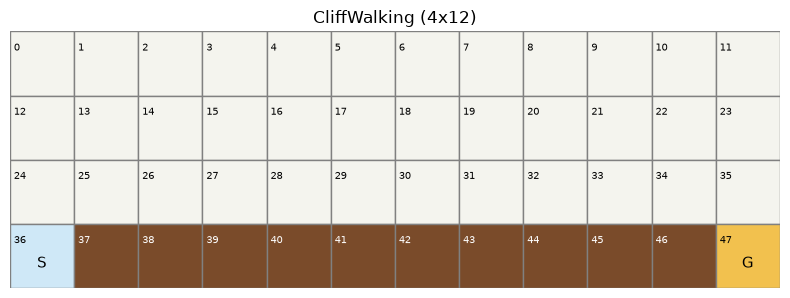

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
draw_cliff(ax, numbers=True, title="CliffWalking (4x12)")
fig.tight_layout()
fig.savefig(FIGURES / "ch04_map.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4 × 12 のマス目に、番号を書いた地図が出ます。スタート（`S`、水色）は左下の 36、ゴール（`G`、黄色）は右下の 47 で、その間の 37〜46 の 10 マス（茶色）が崖です。スタートからゴールへの最短の道は、上の 24 へ 1 歩、右へ 11 歩、下のゴールへ 1 歩の、13 歩です。

報酬は、1 歩ごとに -1 です。崖へ踏み出した 1 歩だけは、-1 の代わりに -100 になります。ゴールに着くと、`terminated` でエピソードが終わります。報酬の合計は、かかった歩数が多いほど、崖に落ちた回数が多いほど小さく（マイナスが大きく）なります。最短の 13 歩でゴールに着いたときの -13 が、この環境で得られる報酬の合計の最大です。

### 3-3. 崖に落ちる

スタート（状態 36）から、右（`RIGHT`、行動 1）・上（`UP`、行動 0）・右（`RIGHT`）の順に3歩進めます。1歩目は、右隣の崖へ踏み出すことになります。

In [4]:
state, info = env.reset(seed=0)
for action in [1, 0, 1]:  # RIGHT（右隣は崖）、UP、RIGHT
    next_state, reward, terminated, truncated, info = env.step(action)
    print(f"状態 {state} で {ACTION_NAMES[action]:5s} → 状態 {next_state}、報酬 {reward}、terminated={terminated}")
    state = next_state
print("状態 36 で RIGHT を選んだときの行き先の表 P:", env.unwrapped.P[36][1])

状態 36 で RIGHT → 状態 36、報酬 -100、terminated=False
状態 36 で UP    → 状態 24、報酬 -1、terminated=False
状態 24 で RIGHT → 状態 25、報酬 -1、terminated=False
状態 36 で RIGHT を選んだときの行き先の表 P: [(1.0, np.int64(36), -100, False)]


**期待する結果**（上の出力の読み方）: 1行目は、36 で `RIGHT` を選んだ場合です。右隣の 37 は崖なので、報酬 -100 を受けて、スタートの 36 に戻されています。`terminated=False` で、エピソードは終わりません。2・3行目は、ふつうの床の上を進んだ場合で、報酬は -1 です。

最後の行の `P` のとおり、36 で `RIGHT` を選ぶと、確率 1.0 で、報酬 -100 とともに 36 へ戻ります。既定の CliffWalking は滑らないので、同じ状態で同じ行動を選ぶと、いつも同じ結果になります。

### 3-4. でたらめに歩く

でたらめに行動を選んで、ゴールに着くまで歩かせます。これを 5 回繰り返し、かかった回数・報酬の合計・崖に落ちた回数を数えます。

In [5]:
env.action_space.seed(100)
for i in range(5):
    state, info = env.reset(seed=100 if i == 0 else None)
    steps, total, falls = 0, 0, 0
    while True:
        state, reward, terminated, truncated, info = env.step(env.action_space.sample())
        steps += 1
        total += reward
        falls += reward == -100
        if terminated:
            break
    print(f"{i + 1} 回目: {steps:6,d} 回でゴール、報酬の合計 {total:9,d}、崖に落ちた回数 {falls:5,d}")

1 回目:  4,522 回でゴール、報酬の合計   -44,221、崖に落ちた回数   401
2 回目:  6,355 回でゴール、報酬の合計   -66,250、崖に落ちた回数   605
3 回目:    287 回でゴール、報酬の合計    -2,762、崖に落ちた回数    25


4 回目: 29,073 回でゴール、報酬の合計  -310,728、崖に落ちた回数 2,845
5 回目:    194 回でゴール、報酬の合計    -1,976、崖に落ちた回数    18


**期待する結果**（上の出力の読み方）: でたらめに歩くと、ゴールに着くまでに 194〜29,073 回かかり、回によって大きく違います。報酬の合計は -1,976〜-310,728、崖に落ちた回数は 18〜2,845 回です。どの回も、報酬の合計の大部分は、崖に落ちたときの -100 です（たとえば 4 回目は、2,845 回 × -100 = -284,500）。

## 4. 動かして楽しむ：SARSA と Q学習のサンプルを動かす

### 4-1. 学習させる

用意したサンプルで、SARSA と Q学習に、それぞれエピソードを 500 回経験させます。2つの手法は同じ関数 `td_control` で動き、引数 `method` だけが違います。サンプルの中身は6節で読むので、ここでは実行して結果を見てください。

In [6]:
# 状態 state で Q 値が最大の行動を1つ返す（最大の行動が複数あれば、その中からでたらめに選ぶ）
def greedy_action(q_table, state, rng):
    best = np.flatnonzero(q_table[state] == q_table[state].max())
    return int(rng.choice(best))


# ε-greedy: 確率 epsilon ででたらめに、残りは Q 値が最大の行動を選ぶ
def epsilon_greedy(q_table, state, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(q_table.shape[1]))
    return greedy_action(q_table, state, rng)


# SARSA（method="sarsa"）または Q学習（method="q"）で episodes 回のエピソードを経験させ、
# Q 表と、エピソードごとの報酬の合計と、エピソードごとの崖に落ちた回数を返す
def td_control(env, method, episodes=500, alpha=0.1, gamma=1.0, epsilon=0.1, seed=0):
    rng = np.random.default_rng(seed)
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = np.zeros(episodes)
    falls = np.zeros(episodes, dtype=int)
    for i in range(episodes):
        state, info = env.reset(seed=seed if i == 0 else None)
        action = epsilon_greedy(q_table, state, epsilon, rng)
        while True:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = epsilon_greedy(q_table, next_state, epsilon, rng)  # 次に実際に選ぶ行動
            if method == "sarsa":
                next_q = q_table[next_state, next_action]  # SARSA: 次に実際に選ぶ行動の Q 値
            else:
                next_q = q_table[next_state].max()  # Q学習: 次の状態での最大の Q 値
            target = reward if terminated else reward + gamma * next_q
            q_table[state, action] += alpha * (target - q_table[state, action])
            rewards[i] += reward
            falls[i] += reward == -100
            state, action = next_state, next_action
            if terminated or truncated:
                break
    return q_table, rewards, falls


results = {}
for method in ["sarsa", "q"]:
    start = time.perf_counter()
    results[method] = td_control(env, method)
    q_table, rewards, falls = results[method]
    print(f"{method:5s}: 学習の時間 {time.perf_counter() - start:.1f} 秒、"
          f"最初のエピソードの報酬の合計 {rewards[0]:,.0f}、"
          f"最後の 100 回の報酬の平均 {rewards[-100:].mean():6.1f}、"
          f"崖に落ちた回数（全体 {falls.sum()} 回、最後の 100 回で {falls[-100:].sum()} 回）")
sarsa_q, sarsa_rewards, sarsa_falls = results["sarsa"]
q_q, q_rewards, q_falls = results["q"]

sarsa: 学習の時間 0.6 秒、最初のエピソードの報酬の合計 -1,274、最後の 100 回の報酬の平均  -22.8、崖に落ちた回数（全体 87 回、最後の 100 回で 5 回）


q    : 学習の時間 0.6 秒、最初のエピソードの報酬の合計 -1,685、最後の 100 回の報酬の平均  -43.5、崖に落ちた回数（全体 175 回、最後の 100 回で 27 回）


**期待する結果**（上の出力の読み方）: 学習にかかった時間は、2つとも著者の環境で 0.6 秒でした（パソコンによって変わります）。最初のエピソードの報酬の合計は、SARSA が -1,274、Q学習が -1,685 で、どちらも -1,000 を下回っています。学習中の最後の 100 回の報酬の平均は、SARSA が -22.8、Q学習が -43.5 で、SARSA のほうが高くなりました。崖に落ちた回数も、SARSA は全体で 87 回（最後の 100 回で 5 回）、Q学習は全体で 175 回（最後の 100 回で 27 回）で、Q学習のほうが多く落ちています。

学習の seed（`td_control` の `seed=0`）と、環境の最初の `reset` の seed を固定しているので、同じ版のライブラリなら、時間以外は何度実行しても同じ結果になります。割引率は `gamma=1.0`（割り引かない）にしています。この環境はゴールに着けば必ず終わり、そこまでの報酬は 1 歩ごとの -1 と、落ちたときの -100 だけなので、割り引かなくても報酬の合計が求まります。

### 4-2. 学んだ道を見る

学習した Q 表から、各マスで Q 値が最大の行動を選ぶ方策を作り、スタートから歩かせます。ここでは、学習中とは違い、でたらめな行動を混ぜません。

SARSA: 15 歩、ゴールに着いたか True、通った道 [36, 24, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 35, 47]
Q学習: 13 歩、ゴールに着いたか True、通った道 [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]


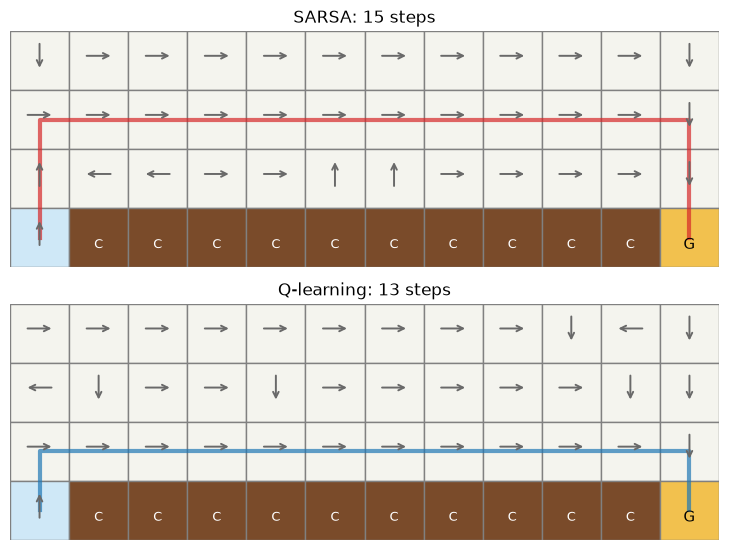

In [7]:
sarsa_policy = sarsa_q.argmax(axis=1)
q_policy = q_q.argmax(axis=1)
sarsa_path, sarsa_goal = greedy_path(env, sarsa_policy)
q_path, q_goal = greedy_path(env, q_policy)
print(f"SARSA: {len(sarsa_path) - 1} 歩、ゴールに着いたか {sarsa_goal}、通った道 {sarsa_path}")
print(f"Q学習: {len(q_path) - 1} 歩、ゴールに着いたか {q_goal}、通った道 {q_path}")

fig, axes = plt.subplots(2, 1, figsize=(8, 5.6))
draw_cliff(axes[0], policy=sarsa_policy, path=sarsa_path, title=f"SARSA: {len(sarsa_path) - 1} steps")
draw_cliff(axes[1], policy=q_policy, path=q_path, path_color="tab:blue", title=f"Q-learning: {len(q_path) - 1} steps")
fig.tight_layout()
fig.savefig(FIGURES / "ch04_paths.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: SARSA の学んだ道は 15 歩です。スタートから上へ 2 マス進み、上から2段目（12〜23）を右へ進んで、右端で下りてゴールに着きます。Q学習の学んだ道は 13 歩です。上へ 1 マスだけ進み、崖のすぐ上の段（24〜35）を右へ進む、最短の道です。図の赤い線が SARSA の道、青い線が Q学習の道で、矢印は各マスで選ぶ向きです。

でたらめな行動を混ぜずに歩かせると、Q学習の道のほうが 2 歩短く、報酬の合計は、得られる最大の -13 です。それなのに、4-1節の学習中の報酬は、SARSA のほうが高くなっていました。この食い違いは、6節で読み解きます。

### 4-3. 歩く様子を見る

2つの道を、1歩ずつ並べて GIF に保存します。早くゴールに着いた側は、ゴールで待ちます。

GIF の枚数: 21


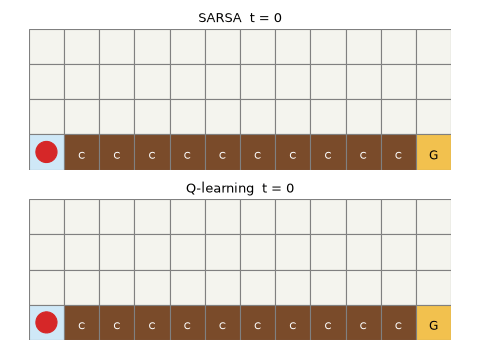

In [8]:
n_frames = max(len(sarsa_path), len(q_path))
frames = []
for t in range(n_frames):
    fig, axes = plt.subplots(2, 1, figsize=(6, 4.4), dpi=80)
    draw_cliff(axes[0], state=sarsa_path[min(t, len(sarsa_path) - 1)], path=sarsa_path[:t + 1], title=f"SARSA  t = {t}")
    draw_cliff(axes[1], state=q_path[min(t, len(q_path) - 1)], path=q_path[:t + 1], path_color="tab:blue",
               title=f"Q-learning  t = {t}")
    fig.tight_layout()
    fig.canvas.draw()
    frames.append(np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy())
    plt.close(fig)
imageio.v3.imwrite(FIGURES / "ch04_walk.gif", frames + [frames[-1]] * 5, duration=400, loop=0)
print("GIF の枚数:", len(frames) + 5)
Image(filename=FIGURES / "ch04_walk.gif")

**期待する結果**（上の出力の読み方）: GIF には、1 歩ごとの図 16 枚（長いほうの SARSA の 15 歩に合わせて、t = 0〜15）に、最後の図を 5 枚足した 21 枚を書き込みます（ゴールに着いた所で少し止めるため）。1 枚を 400 ミリ秒で表示します。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、2つの道を並べた GIF です。上の SARSA は上から2段目を通って 15 歩で、下の Q学習は崖のすぐ上の段を通って 13 歩で、ゴールに着きます。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 と、public にした後の 2026-10-10 に確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じ道のりのコマ送りの図を作ります。

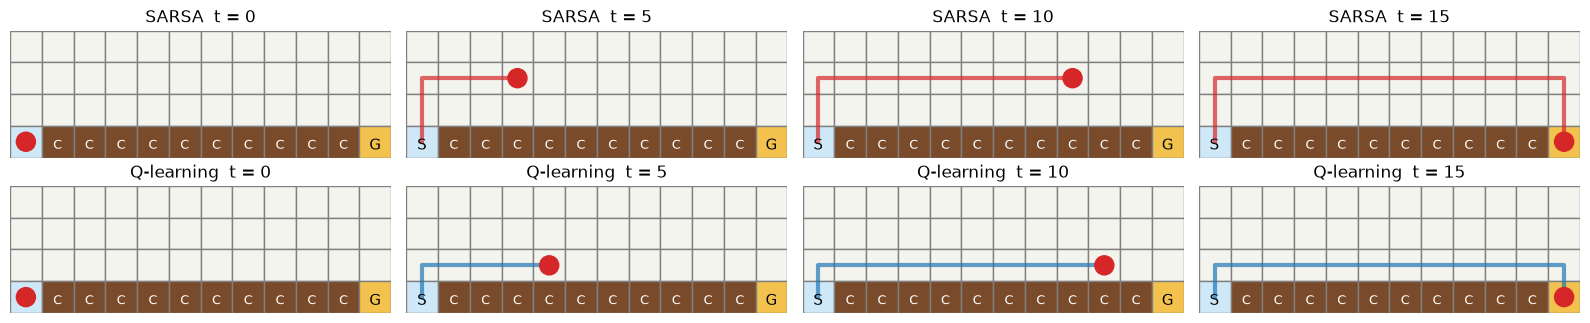

In [9]:
picks = np.linspace(0, n_frames - 1, 4).round().astype(int)
fig, axes = plt.subplots(2, 4, figsize=(16, 3.4))
for j, t in enumerate(picks):
    draw_cliff(axes[0, j], state=sarsa_path[min(t, len(sarsa_path) - 1)], path=sarsa_path[:t + 1], title=f"SARSA  t = {t}")
    draw_cliff(axes[1, j], state=q_path[min(t, len(q_path) - 1)], path=q_path[:t + 1], path_color="tab:blue",
               title=f"Q-learning  t = {t}")
fig.tight_layout()
fig.savefig(FIGURES / "ch04_walk_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 等間隔に 4 つの時点（t = 0・5・10・15）を選んだコマ送りです。上の段が SARSA、下の段が Q学習です。t = 5 では、SARSA は上から2段目を、Q学習は崖のすぐ上の段を進んでいます。t = 15 では、SARSA はゴールに着いたところで、13 歩でゴールに着いた Q学習は、ゴールで待っています。

### 4-4. 学習曲線を見る

学習中のエピソードごとの報酬の合計を、直前 20 回の平均にして、2つの手法を重ねて描きます。最初のほうのエピソードは報酬の合計がとても小さい（4-1節の出力のとおり、最初のエピソードは -1,000 を下回る）ので、縦軸は -150〜0 の範囲だけを表示します。

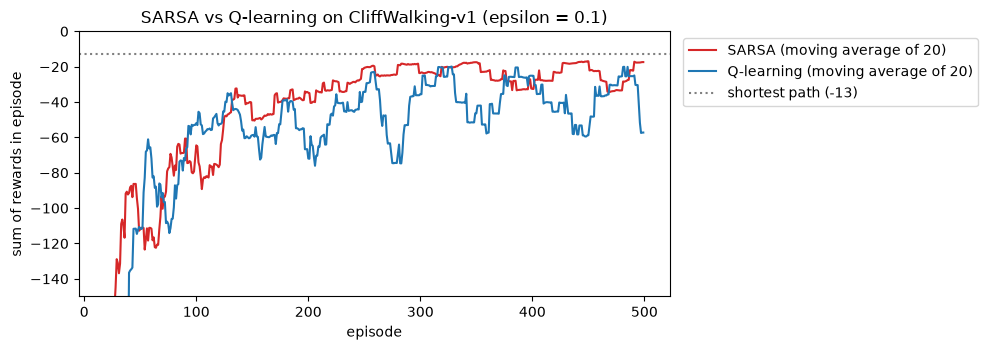

In [10]:
window = 20
fig, ax = plt.subplots(figsize=(10, 3.6))
for rewards, label, color in [(sarsa_rewards, "SARSA", "tab:red"), (q_rewards, "Q-learning", "tab:blue")]:
    moving = np.convolve(rewards, np.ones(window) / window, mode="valid")
    ax.plot(np.arange(window - 1, len(rewards)), moving, color=color, label=f"{label} (moving average of {window})")
ax.axhline(-13, color="gray", linestyle=":", label="shortest path (-13)")
ax.set_xlabel("episode")
ax.set_ylabel("sum of rewards in episode")
ax.set_ylim(-150, 0)
ax.set_title("SARSA vs Q-learning on CliffWalking-v1 (epsilon = 0.1)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
fig.savefig(FIGURES / "ch04_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 赤い線が SARSA、青い線が Q学習の、学習中のエピソードごとの報酬の合計（直前 20 回の平均）です。灰色の点線は、最短の道の報酬の合計 -13 です。最初の 100 回ほどは、どちらも -100 を下回る所から上がっていきます。200 回あたりから後は、SARSA の線はおおむね -30〜-15 の間にあり、Q学習の線は -75〜-20 ほどの間を大きく上下して、ほとんどの時点で SARSA の線より下にあります。どちらの線も、-13 には届きません。

学習中の報酬が -13 に届かないことと、SARSA のほうが高いことの理由は、6-3節で確かめます。

## 5. 読む(1)：Q 表

各マスで最大の Q 値（その状態の価値の見積もり）と、選ぶ向きを、2つの手法で並べて描きます。割引率が 1 なので、Q 値は「そこからゴールまでに得る報酬の合計の見積もり」で、崖に落ちなければ、およそ「ゴールまでの残りの歩数」にマイナスを付けた値になります。

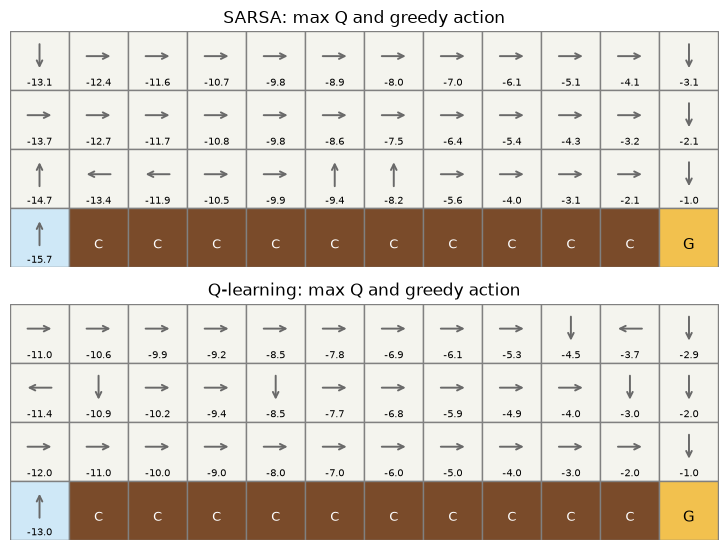

崖のすぐ上の段（状態 24〜35）の最大の Q 値:
SARSA: [-14.7 -13.4 -11.9 -10.5  -9.9  -9.4  -8.2  -5.6  -4.   -3.1  -2.1  -1. ]
Q学習: [-12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.]


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5.6))
draw_cliff(axes[0], values=sarsa_q.max(axis=1), policy=sarsa_policy, title="SARSA: max Q and greedy action")
draw_cliff(axes[1], values=q_q.max(axis=1), policy=q_policy, title="Q-learning: max Q and greedy action")
fig.tight_layout()
fig.savefig(FIGURES / "ch04_q_values.png", dpi=80)
plt.show()

print("崖のすぐ上の段（状態 24〜35）の最大の Q 値:")
print("SARSA:", np.round(sarsa_q[24:36].max(axis=1), 1))
print("Q学習:", np.round(q_q[24:36].max(axis=1), 1))

**期待する結果**（上の出力の読み方）: 上が SARSA、下が Q学習の、各マスの最大の Q 値（下の数）と、選ぶ向き（矢印）です。最後の2行は、崖のすぐ上の段（状態 24〜35）の値を取り出したものです。

Q学習のこの段の値は、左から -12、-11、…、-1 と、ちょうど「そこからゴールまでの最短の歩数」にマイナスを付けた値で、スタートの値も -13.0 です。SARSA のこの段の値は、右端の 4 マス（32〜35）では Q学習とほぼ同じですが、左へ行くほど Q学習より小さく（マイナスが大きく）なります（たとえば状態 25 では、SARSA が -13.4、Q学習が -11.0）。SARSA のスタートの値は -15.7 です。

同じ環境で、同じように歩き回って学んだのに、崖のそばのマスの値の見積もりが、2つの手法で違っています。この違いがどこから来るのかを、6節でサンプルを読んで確かめます。

## 6. 読む(2)：SARSA と Q学習のサンプル

4-1節のサンプルを読みます。行動の選び方（ε-greedy）と、Q 値を少しずつ目標へ近づける書き換え方は、第3章の6節の Q学習と同じです。

### 6-1. 違いは1行だけ

```python
next_action = epsilon_greedy(q_table, next_state, epsilon, rng)  # 次に実際に選ぶ行動
if method == "sarsa":
    next_q = q_table[next_state, next_action]  # SARSA: 次に実際に選ぶ行動の Q 値
else:
    next_q = q_table[next_state].max()  # Q学習: 次の状態での最大の Q 値
target = reward if terminated else reward + gamma * next_q
```

2つの手法の違いは、目標（`target`）に使う「次の状態の Q 値」だけです。式で書くと次のようになります。$s$ は今の状態、$a$ は選んだ行動、$r$ は得た報酬、$s'$ は次の状態、$a'$ は次の状態で実際に選ぶ行動です。

- **SARSA**: $Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma Q(s', a') - Q(s, a) \right)$
- **Q学習**: $Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right)$

SARSA は、次の状態で ε-greedy が実際に選んだ行動 $a'$ の Q 値を使います。$a'$ は、確率 0.9 で Q 値が最大の行動ですが、確率 0.1 ででたらめな行動になります。Q学習は、次に実際に何を選ぶかに関係なく、最大の Q 値を使います。

SARSA という名前は、1回の書き換えに使う5つの値、今の状態（State）・選んだ行動（Action）・得た報酬（Reward）・次の状態（State）・次の行動（Action）の頭文字を並べたものです。次の行動 $a'$ を書き換えの前に決めておく必要があるので、`td_control` では、`next_action` を先に選び、次の1歩でそのまま使っています（`state, action = next_state, next_action`）。Q学習の場合も、同じ順番で行動を選んでいます。

### 6-2. 数字で確かめる

4節で SARSA が学んだ Q 表を使って、同じ1回の経験から、2つの手法の目標がどう違うかを計算します。経験は「崖のすぐ上の状態 25 で `RIGHT` を選び、状態 26 へ進んで報酬 -1 を得た。次の状態 26 では、ε-greedy のでたらめで `DOWN`（崖へ）を選んだ」とします。Q 表そのものは書き換えないように、値を取り出して計算します。

In [12]:
alpha, gamma = 0.1, 1.0
q = sarsa_q  # 4節で SARSA が学んだ Q 表
before = q[25, 1]  # Q(25, RIGHT)
sarsa_target = -1 + gamma * q[26, 2]  # 次に実際に選ぶ行動（DOWN）の Q 値を使う
q_target = -1 + gamma * q[26].max()  # 次の状態での最大の Q 値を使う
print(f"今の Q(25, RIGHT) = {before:.1f}")
print(f"Q(26, 各行動) = {np.round(q[26], 1)}（UP, RIGHT, DOWN, LEFT）")
print(f"SARSA の目標 = {sarsa_target:.1f} → 更新後 {before + alpha * (sarsa_target - before):.1f}")
print(f"Q学習の目標 = {q_target:.1f} → 更新後 {before + alpha * (q_target - before):.1f}")

今の Q(25, RIGHT) = -16.8
Q(26, 各行動) = [-12.  -14.2 -60.6 -11.9]（UP, RIGHT, DOWN, LEFT）
SARSA の目標 = -61.6 → 更新後 -21.3
Q学習の目標 = -12.9 → 更新後 -16.4


**期待する結果**（上の出力の読み方）: 今の Q(25, `RIGHT`) は -16.8 です。次の状態 26 の Q 値は、`UP` が -12.0、`RIGHT` が -14.2、`DOWN` が -60.6、`LEFT` が -11.9 で、崖へ踏み出す `DOWN` だけが大きなマイナスです。

SARSA の目標は、実際に選んだ `DOWN` の Q 値を使うので -1 + (-60.6) = -61.6 となり、Q(25, `RIGHT`) は -21.3 へ大きく下がります。Q学習の目標は、最大の `LEFT` の Q 値を使うので -1 + (-11.9) = -12.9 となり（最大は戻る向きの `LEFT` ですが、`UP` の -12.0 とほとんど差はありません）、Q(25, `RIGHT`) は -16.4 へ少し上がります。

崖のすぐ上の段では、ε-greedy がでたらめな行動を選び（確率 0.1）、しかもそれが `DOWN`（4 つのうちの 1 つ）になると、崖へ踏み出します。1 歩あたり 0.1 × 1/4 = 0.025 の確率です。SARSA では、このようなでたらめな行動が次の行動になるたびに、目標が大きく下がり、崖のそばのマスへ進む行動の Q 値が下がります。Q学習は、次に実際に選んだ行動がどれだけ悪くても、目標には最大の Q 値しか使わないので、崖のそばの Q 値が、でたらめな行動のせいで下がることはありません。5節の図で、SARSA の崖のすぐ上の段の値が Q学習より小さかったのは、この書き換え方の違いによるものです。

### 6-3. 方策オンと方策オフ

SARSA の目標には、でたらめに選んだ行動の Q 値も入ります。そのため SARSA の Q 表は、「でたらめな行動を確率 0.1 で混ぜながら歩いたときに得る報酬の合計」を見積もることになります。経験を集める方策（ε-greedy）と、見積もっている方策が同じなので、SARSA は**方策オン**の手法です。

Q学習の目標は、次の状態でいつも最も良い行動を選ぶとしたときの値です。Q学習の Q 表は、「でたらめな行動を混ぜずに歩いたときに得る報酬の合計」を見積もります。経験を集める方策（ε-greedy）と、見積もっている方策（いつも最も良い行動を選ぶ方策）が別なので、Q学習は**方策オフ**の手法です。

この違いを、成績で確かめます。2つの手法が学んだ Q 表を使い、でたらめな行動を混ぜない場合（`epsilon=0`）と、学習中と同じ割合で混ぜる場合（`epsilon=0.1`）で、それぞれ 1,000 回歩かせて、報酬の合計の平均を測ります。

In [13]:
# Q 表から ε-greedy で行動を選んで episodes 回歩かせ、報酬の合計の平均を返す
def mean_return(env, q_table, epsilon, episodes=1000, seed=100, max_steps=1000):
    rng = np.random.default_rng(seed)
    totals = np.zeros(episodes)
    for i in range(episodes):
        state, info = env.reset(seed=seed if i == 0 else None)
        for _ in range(max_steps):
            action = epsilon_greedy(q_table, state, epsilon, rng)
            state, reward, terminated, truncated, info = env.step(action)
            totals[i] += reward
            if terminated:
                break
    return totals.mean()


print("               epsilon=0   epsilon=0.1")
for name, q_table in [("SARSA", sarsa_q), ("Q学習", q_q)]:
    print(f"{name}の Q 表:  {mean_return(env, q_table, 0.0):8.1f}   {mean_return(env, q_table, 0.1):10.1f}")

               epsilon=0   epsilon=0.1


SARSAの Q 表:     -15.0        -21.0


Q学習の Q 表:     -13.0        -49.5


**期待する結果**（上の出力の読み方）: でたらめな行動を混ぜない場合（`epsilon=0`）は、SARSA の Q 表で -15.0、Q学習の Q 表で -13.0 で、4-2節で見た道の歩数のとおり、Q学習のほうが良い成績です。学習中と同じ割合で混ぜる場合（`epsilon=0.1`）は、SARSA が -21.0、Q学習が -49.5 で、逆に SARSA のほうがずっと良い成績です。`epsilon=0.1` の値は、4-1節の学習中の最後の 100 回の平均（SARSA が -22.8、Q学習が -43.5）に近い値です。

`mean_return` は、学習した Q 表から `epsilon_greedy` で行動を選んで歩かせる関数です。崖に落ちてもエピソードは終わらないので、`max_steps`（既定は 1,000）歩でゴールに着かなければ打ち切ります。

2つの手法は、どちらも、自分が見積もっている方策のもとで良い成績を出しています。SARSA が学んだのは、「でたらめな行動を混ぜても崖に落ちにくい」遠回りの道で、Q学習が学んだのは、「でたらめな行動を混ぜなければ最も短い」崖のふちの道です。学習中は、どちらも ε-greedy で歩くので、崖のふちを歩く Q学習は、でたらめな行動でときどき崖に落ち、学習中の報酬が SARSA より低くなっていました（4-1節・4-4節）。

どちらの道が良いかは、学んだ方策をどう使うかで決まります。この章の CliffWalking では、学んだあと、でたらめな行動を混ぜずに歩かせるなら Q学習の道のほうが、使うときにも同じ割合ででたらめな行動が混ざるなら SARSA の道のほうが、報酬の合計が大きくなりました。

## 7. 遊んでみる

### 7-1. でたらめな行動を増やす

学習中にでたらめな行動を混ぜる割合を、`epsilon=0.1` から `epsilon=0.3` に増やして、2つの手法を学ばせ直します。

SARSA: 学んだ道 17 歩（ゴールに着いたか True）、学習中の最後の 100 回の報酬の平均 -46.5


Q学習: 学んだ道 13 歩（ゴールに着いたか True）、学習中の最後の 100 回の報酬の平均 -166.7


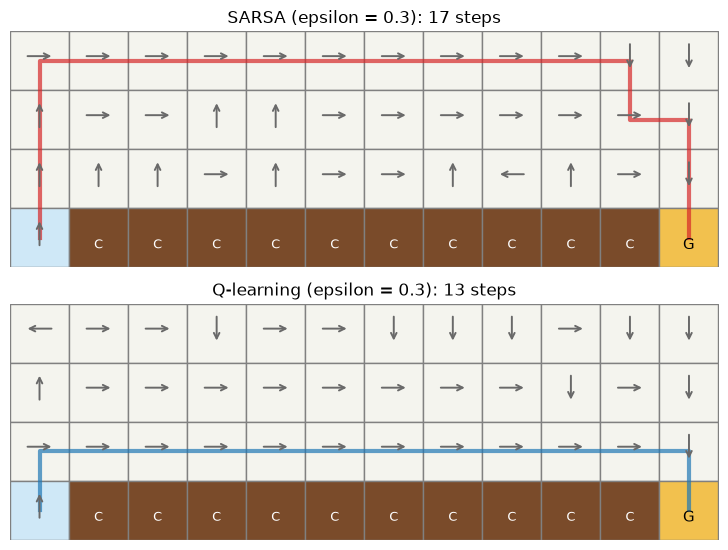

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5.6))
for ax, method, color in zip(axes, ["sarsa", "q"], ["tab:red", "tab:blue"]):
    q_table, rewards, falls = td_control(env, method, epsilon=0.3)
    path, reached = greedy_path(env, q_table.argmax(axis=1))
    name = "SARSA" if method == "sarsa" else "Q学習"
    print(f"{name}: 学んだ道 {len(path) - 1} 歩（ゴールに着いたか {reached}）、"
          f"学習中の最後の 100 回の報酬の平均 {rewards[-100:].mean():.1f}")
    draw_cliff(ax, policy=q_table.argmax(axis=1), path=path, path_color=color,
               title=f"{'SARSA' if method == 'sarsa' else 'Q-learning'} (epsilon = 0.3): {len(path) - 1} steps")
fig.tight_layout()
plt.show()

**期待する結果**（上の出力の読み方）: `epsilon=0.3` では、SARSA の学んだ道は 17 歩になり、4節（15 歩）よりさらに崖から離れます。スタートからいちばん上の段まで上がって右端の手前の状態 10 まで進み、1段下りて 22 へ、右へ1マス進んで 23 へ移ってから、右端の列を下りてゴールに着きます（10 → 22 → 23 → 35 → 47）。Q学習の学んだ道は 13 歩のままで、崖のふちを通ります。学習中の最後の 100 回の報酬の平均は、SARSA が -46.5、Q学習が -166.7 で、4節（-22.8・-43.5）よりどちらも下がり、2つの差も広がっています。

### 7-2. 学習の seed を変える

4節の結果が、学習の seed（でたらめな選び方）を変えても同じかを確かめます。`epsilon=0.1` に戻し、seed を 0〜9 に変えて、学んだ道の歩数と、学習中の最後の 100 回の報酬の平均を並べます。著者の環境では、このセル全体で 10 秒ほどかかりました。

In [15]:
for method in ["sarsa", "q"]:
    steps, finals = [], []
    for seed in range(10):
        q_table, rewards, falls = td_control(env, method, seed=seed)
        path, reached = greedy_path(env, q_table.argmax(axis=1))
        steps.append(len(path) - 1 if reached else "-")
        finals.append(f"{rewards[-100:].mean():.0f}")
    name = "SARSA" if method == "sarsa" else "Q学習"
    print(f"{name}: 学んだ道の歩数 {steps}")
    print(f"{name}: 最後の 100 回の報酬の平均 {finals}")

SARSA: 学んだ道の歩数 [15, 17, 15, 15, 15, 15, 15, 15, 17, 15]
SARSA: 最後の 100 回の報酬の平均 ['-23', '-21', '-20', '-22', '-19', '-25', '-22', '-19', '-21', '-22']


Q学習: 学んだ道の歩数 [13, 13, 13, 13, 13, 13, 13, 13, 13, 13]
Q学習: 最後の 100 回の報酬の平均 ['-44', '-49', '-48', '-44', '-54', '-50', '-59', '-40', '-47', '-61']


**期待する結果**（上の出力の読み方）: seed を 0〜9 に変えても、Q学習の学んだ道は、10 回すべて 13 歩でした。SARSA の学んだ道は、10 回のうち 8 回が 15 歩、2 回（seed = 1・8）が 17 歩で、どれも Q学習より長い遠回りの道です。学習中の最後の 100 回の報酬の平均は、SARSA が -25〜-19、Q学習が -61〜-40 で、どの seed でも SARSA のほうが高くなりました。

**やってみよう**:

- 4-1節の `td_control(env, method)` を `td_control(env, method, epsilon=0.01)` に変えて、そこから下を実行し直してみてください。著者が学習の seed を 0〜2 に変えて試したところ、Q学習の学んだ道はどれも 13 歩で、学習中の最後の 100 回の報酬の平均も -14.3〜-13.1 と、-13 にほぼ届きました。SARSA は、seed = 2 では 13 歩の道を学びましたが、seed = 0・1 では、学んだ方策で歩かせると、100 歩のうちにゴールに着きませんでした（`greedy_path` が `False` を返します）
- `gym.make("CliffWalkingSlippery-v1")` で、滑る崖を作れます（第3章の FrozenLake と同じく、選んだ向きへ進めるのは確率 1/3 で、残りは左右の向きへ滑ります）。著者が4節と同じ設定（500 回、seed = 0）で試したところ、6-3節の `mean_return` で測った報酬の合計の平均は、`epsilon=0` で SARSA が -94.4、Q学習が -74.5、`epsilon=0.1` で SARSA が -151.0、Q学習が -151.8 でした。滑らない崖とは、結果の様子が違います

## 8. まとめ

この章では、CliffWalking を、SARSA と Q学習の2つの手法で解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 地図・崖に落ちたとき・でたらめな歩きの報酬を見る | `step()`、`P` | 3節 |
| SARSA と Q学習で学ばせ、学んだ道・歩く様子・学習曲線を見る | `td_control()`、`greedy_path()` | 4節 |
| Q 表を読む | `q_table`、`max` | 5節 |
| 2つの手法の違いの1行と、方策オン・方策オフを読む | 更新の式、`mean_return()` | 6節 |
| でたらめな行動の割合と、学習の seed を変えて試す | `epsilon`、`seed` | 7節 |

SARSA と Q学習は、表を書き換える1行（次の状態の Q 値に、次に実際に選ぶ行動の Q 値を使うか、最大の Q 値を使うか）しか違わないのに、CliffWalking では違う道を学びました。方策オフの Q学習は、でたらめな行動を混ぜなければ最も短い、崖のふちの道を学びました。方策オンの SARSA は、でたらめな行動を混ぜながら歩いても報酬が大きい、崖から離れた道を学びました。でたらめな行動を増やすと（7-1節）、SARSA はさらに崖から離れ、Q学習の道は変わりませんでした。

この章でも、第3章と同じく、`epsilon` を学習の間ずっと同じ値にしました。第5章では、マスの数がずっと多い Taxi で、学習が進むにつれて `epsilon` を小さくしていくやり方を扱います。

- 次に読むもの: [第5章 Taxi](../ch05_taxi/ch05_taxi.ipynb)。状態が 500 個ある町で、ε の減衰と行動マスクという探索の工夫を確かめます
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0 の動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。サンプルのコードは著者が書いたものです。

- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd edition, MIT Press, 2018（第6章 TD 学習〈SARSA、Q学習、例 6.6 Cliff Walking〉）
- G. A. Rummery and M. Niranjan, "On-Line Q-Learning Using Connectionist Systems", Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department, 1994
- Farama Foundation, Gymnasium Documentation, Cliff Walking: https://gymnasium.farama.org/environments/toy_text/cliff_walking/
- Farama Foundation, Gymnasium 1.3.0 のソース `gymnasium/envs/toy_text/cliffwalking.py`（行き先の表 `P`、崖に落ちたときの扱い）: https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/toy_text/cliffwalking.py

この章の図と GIF は、著者が matplotlib で描いたものです（Gymnasium の描画の絵は使っていません）。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。